# Catchment areas for Thames gauging stations

Matches EA hydrology stations on the River Thames network to their upstream catchment boundary polygon, via the National River Flow Archive (NRFA) station id (`Station.nrfa_station_id`) and the CAMELS-GB v1 catchment boundary set (`wxdecide.connectors.catchment_boundaries`).

**Why not every station matches.** Only actual river-flow gauges are ever NRFA members — the much larger set of EA stations measuring water quality, rainfall, level-only or groundwater were never eligible in the first place, so we filter to flow gauges (`RIVER_FLOW_TYPE`) before matching rather than comparing against every nearby station. Even among flow gauges, CAMELS-GB only covers 671 of the ~1,500 NRFA gauges nationally (a curated benchmark subset), so we'd still expect roughly a third to match — which is what we see both here and nationally (412 of 1,102 EA flow gauges, ~37%).

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point, shape

from wxdecide.connectors.catchment_boundaries import fetch_camels_gb_boundaries
from wxdecide.connectors.ea_hydrology import EAHydrologyClient, RIVER_FLOW_TYPE
from wxdecide.geo import join_stations_to_catchments, stations_near_river

%matplotlib inline

## Thames-network flow gauges matched to a catchment boundary

In [2]:
THAMES_GEOJSON_PATH = "../data/river_thames.geojson"
BUFFER_METERS = 2000.0

with EAHydrologyClient() as client:
    all_stations = client.get_stations()
    flow_stations = client.get_stations(params={"type": RIVER_FLOW_TYPE})

thames = gpd.read_file(THAMES_GEOJSON_PATH)
near_all = stations_near_river(all_stations, THAMES_GEOJSON_PATH, BUFFER_METERS)
near_flow = stations_near_river(flow_stations, THAMES_GEOJSON_PATH, BUFFER_METERS)
boundaries = fetch_camels_gb_boundaries()

pairs = join_stations_to_catchments(near_flow, boundaries)
print(
    f"{len(near_all)} stations of any type within {BUFFER_METERS:.0f}m of the Thames network, "
    f"only {len(near_flow)} of which are actual river-flow gauges "
    f"(the rest are water-quality/rainfall/groundwater instruments that were never NRFA-eligible)\n"
    f"{len(pairs)} of those {len(near_flow)} flow gauges matched to a CAMELS-GB catchment boundary"
)

258 stations of any type within 2000m of the Thames network, only 34 of which are actual river-flow gauges (the rest are water-quality/rainfall/groundwater instruments that were never NRFA-eligible)
11 of those 34 flow gauges matched to a CAMELS-GB catchment boundary


In [3]:
summary = pd.DataFrame(
    [
        {
            "station": s.label,
            "river": s.river_name,
            "nrfa_station_id": s.nrfa_station_id,
            "area_km2": b.area_km2,
        }
        for s, b in pairs
    ]
).sort_values("area_km2").reset_index(drop=True)
summary

,station,river,nrfa_station_id,area_km2
0,Kingston Hogsmill,Hogsmill River,39012,72.910000
1,Lechlade,River Leach,39042,77.614063
2,Water Eaton,River Ray,39087,81.555625
3,Cerney Wick,River Churn,39035,126.749062
4,Bourne End Hedsor,River Wye,39023,134.177500
5,Pangbourne,River Pang,39027,175.683125
6,Abingdon,River Ock,39081,233.597813
7,Newbridge,River Windrush,39006,361.593125
8,Cassington,River Evenlode,39034,427.143750
9,Windsor,River Thames,39072,7124.951250


## Catchment area by station

Ranges from small headwater tributaries up to the whole Thames catchment at Kingston.

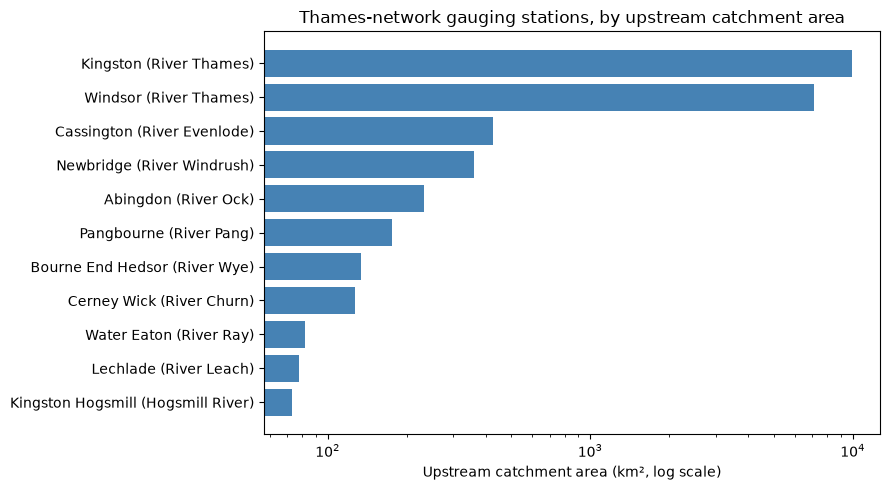

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = summary["station"] + " (" + summary["river"].fillna("unknown") + ")"
ax.barh(labels, summary["area_km2"], color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Upstream catchment area (km², log scale)")
ax.set_title("Thames-network gauging stations, by upstream catchment area")
fig.tight_layout()

## All matched catchments on the map

Catchments are nested — e.g. the Kingston polygon (the whole Thames above Kingston) contains every tributary catchment upstream of it — so smaller polygons are drawn on top for visibility.

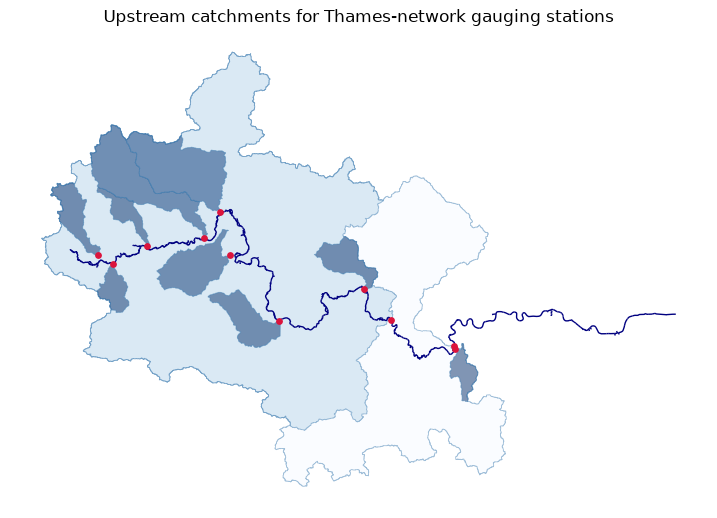

In [5]:
# a couple of stations share an NRFA id (e.g. two nearby gauges on the same reach), so
# dedupe by nrfa_station_id before plotting polygons to avoid drawing one twice
by_nrfa_id = {b.nrfa_station_id: b for _, b in pairs}
catchments = gpd.GeoDataFrame(
    {
        "nrfa_station_id": list(by_nrfa_id.keys()),
        "area_km2": [b.area_km2 for b in by_nrfa_id.values()],
    },
    geometry=[shape(b.geometry) for b in by_nrfa_id.values()],
    crs="EPSG:4326",
).sort_values("area_km2", ascending=False)

station_points = gpd.GeoDataFrame(
    {"station": [s.label for s, _ in pairs]},
    geometry=[Point(s.long, s.lat) for s, _ in pairs],
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(9, 11))
catchments.plot(
    ax=ax, column="area_km2", cmap="Blues_r", alpha=0.5, edgecolor="steelblue", linewidth=0.6
)
thames.plot(ax=ax, linewidth=1, color="navy")
station_points.plot(ax=ax, color="crimson", markersize=15, zorder=5)
ax.set_title("Upstream catchments for Thames-network gauging stations")
ax.set_axis_off()

## A few examples close up

Three stations spanning the size range: the whole Thames catchment at **Kingston** (the tidal limit), a mid-sized tributary catchment on the **River Evenlode** at Cassington, and a small headwater catchment on the **Hogsmill River**.

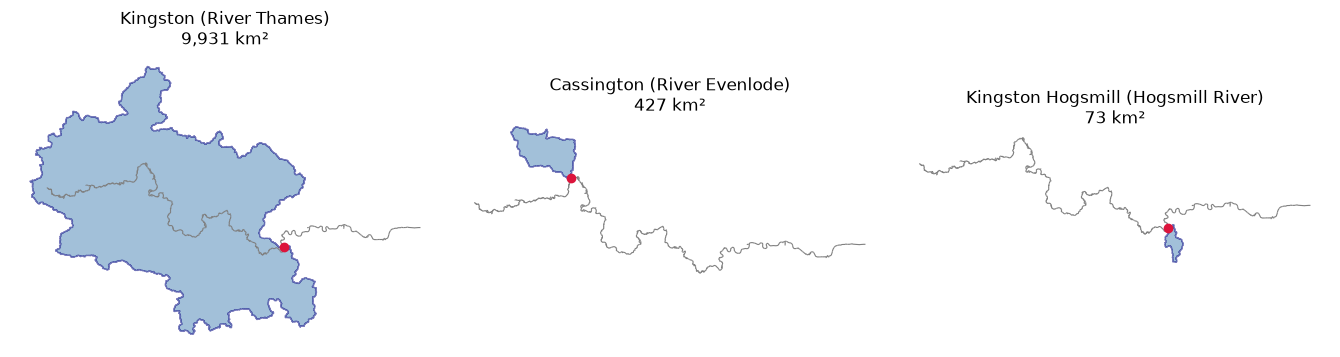

In [6]:
examples = ["Kingston", "Cassington", "Kingston Hogsmill"]

fig, axes = plt.subplots(1, len(examples), figsize=(4.5 * len(examples), 5))
for ax, label in zip(axes, examples):
    row = summary.loc[summary["station"] == label].iloc[0]
    boundary = by_nrfa_id[row["nrfa_station_id"]]
    station = next(s for s, b in pairs if s.label == label)

    gpd.GeoDataFrame(geometry=[shape(boundary.geometry)], crs="EPSG:4326").plot(
        ax=ax, color="steelblue", alpha=0.5, edgecolor="navy"
    )
    thames.plot(ax=ax, linewidth=0.8, color="grey")
    ax.plot(station.long, station.lat, "o", color="crimson", markersize=6)
    ax.set_title(f"{label} ({station.river_name})\n{row['area_km2']:,.0f} km²")
    ax.set_axis_off()
fig.tight_layout()

## Catchment area for a tidal station: Cadogan Pier

Most Thames water-quality stations (like `THAMES_CADOGAN PIER_E_200707`) are not NRFA gauges themselves, so they have no `nrfa_station_id` and no catchment boundary of their own, per the matching above. But Cadogan Pier sits on the *tidal* Thames, downstream of the tidal limit at Teddington/Kingston — so its true drainage area is well approximated by the catchment of the nearest upstream mainstem gauge (**Kingston**, NRFA `39001`, the whole non-tidal Thames catchment) unioned with every tributary catchment that joins the river between Teddington and Cadogan Pier.

Checking actual London geography, three tributaries join upstream of Cadogan Pier (Chelsea) with a catchment boundary in the CAMELS-GB set:

- **River Brent** at Brentford — only its own tributary, **Silk Stream** (NRFA `39049`, gauged at Colindale), has a boundary; the wider Brent itself isn't in the CAMELS-GB set
- **Beverley Brook** at Barn Elms/Putney (NRFA `39005`, gauged at Wimbledon Common)
- **River Wandle** at Wandsworth (NRFA `39004`, gauged at Beddington Park)

Each tributary's gauge sits well upstream of its actual confluence with the Thames, so these understate each tributary's true contribution somewhat — but they're real, non-overlapping additional area (confirmed by checking they're <5% contained within Kingston's polygon), so unioning them in is a genuine improvement over reusing Kingston's catchment alone.

In [7]:
from shapely.geometry import shape
from sqlmodel import Session, select

from wxdecide.database.engine import get_engine
from wxdecide.database.tables import CatchmentBoundaryTable
from wxdecide.geo import union_catchment_boundaries

CADOGAN_PIER_NRFA_IDS = {
    "39001": "Kingston (whole Thames to tidal limit)",
    "39004": "River Wandle (Beddington Park)",
    "39005": "Beverley Brook (Wimbledon Common)",
    "39049": "Silk Stream (Colindale, a Brent tributary)",
}

with Session(get_engine()) as session:
    cadogan_boundaries = session.exec(
        select(CatchmentBoundaryTable).where(
            CatchmentBoundaryTable.nrfa_station_id.in_(CADOGAN_PIER_NRFA_IDS)
        )
    ).all()

for b in sorted(cadogan_boundaries, key=lambda b: b.area_km2):
    print(f"{b.area_km2:>10.2f} km2  {CADOGAN_PIER_NRFA_IDS[b.nrfa_station_id]}")

cadogan_pier_union = union_catchment_boundaries(cadogan_boundaries)
print()
print(f"Sum of individual areas: {sum(b.area_km2 for b in cadogan_boundaries):,.2f} km2 (the union's own area is the same here, since none of these four overlap)")

     31.07 km2  Silk Stream (Colindale, a Brent tributary)
     39.49 km2  Beverley Brook (Wimbledon Common)
    117.35 km2  River Wandle (Beddington Park)
   9930.83 km2  Kingston (whole Thames to tidal limit)

Sum of individual areas: 10,118.74 km2 (the union's own area is the same here, since none of these four overlap)


### Visualising the union

Each tributary catchment plotted separately, then the combined (unioned) outline on top, against the Thames for geographic context.

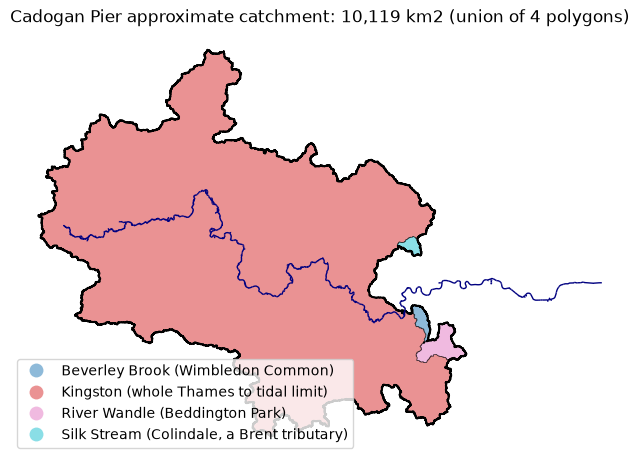

In [8]:
cadogan_gdf = gpd.GeoDataFrame(
    {
        "label": [CADOGAN_PIER_NRFA_IDS[b.nrfa_station_id] for b in cadogan_boundaries],
        "area_km2": [b.area_km2 for b in cadogan_boundaries],
    },
    geometry=[shape(b.geometry) for b in cadogan_boundaries],
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(8, 10))

# Individual catchments, largest-first so the small tributaries still draw on top and stay visible
cadogan_gdf.sort_values("area_km2", ascending=False).plot(
    ax=ax, column="label", legend=True, alpha=0.5, edgecolor="black", linewidth=0.5,
    legend_kwds={"loc": "lower left"},
)

# The unioned outline, drawn as a bold outline on top
gpd.GeoSeries([shape(cadogan_pier_union)], crs="EPSG:4326").boundary.plot(
    ax=ax, color="black", linewidth=1.5,
)

thames = gpd.read_file("../data/river_thames.geojson")
thames.plot(ax=ax, linewidth=1.0, color="navy", zorder=5)
total_area_km2 = sum(b.area_km2 for b in cadogan_boundaries)
ax.set_title(f"Cadogan Pier approximate catchment: {total_area_km2:,.0f} km2 (union of {len(cadogan_boundaries)} polygons)")
ax.set_axis_off()